# DAPPC LAB 3 - Identification of relevant features for subgroups of patients

This notebook guides you in the implementation of the Ant-Colony Optimization (ACO) algorithm to perform Feature Selection (FS).

## Recommended workflow
1. Load the dataset obtained after the previous laboratory steps.
2. Identify the most populated SOM cluster containing samples from all outcome classes of interest.
3. Initialize the main paramters of the ACO algorithm.
4. Run ACO-based feature selection.
5. Analyze convergence, the selected feature subset, and final predictive performance.


## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.io import save_versioned, load_latest, raw_path, get_output_dir

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import ACO
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
output_dir = get_output_dir(3)
plt.rcParams['figure.figsize'] = (9, 4)


Output directory: LAB3/outputs/20260617_210615


## 1. Load data

Load the four sets of clusters obtained at the end of LAB2: the best set of clusters of each of the four datasets (each SOM)

In [2]:
# Dataset used for ACO: one of the 4 imputed versions from LAB1.
# Change DS_KEY to '3b', '3c', or '3d' to use a different imputation.
DS_KEY = '3a'

cluster_df = load_latest('LAB1_knn_imputed_global')


Loading → LAB1/outputs/20260617_205857/LAB1_knn_imputed_global.xlsx


## 2. Select the largest valid SOM cluster

We will perform feature selection (FS) with Ant-Colony Optimization (ACO) algorithm only on two clusters. Identify them as follows:
1. Identify the best set of cluster as the one with minimum value of maximum intra-cluster variability: you choose the best SOM.
2. Remove the clusters where all the three classes are not present.
3. Remove the clusters that are too small (it depends on the distribution of the patients within the different clusters).
4. Identify the two more distant clusters (inter-cluster distances computed on the centroids).


In [3]:
id_cols = ['subject_id', 'hadm_id', 'stay_id', 'ICU', 'ICU_intime', 'ICU_outtime']
outcome_col = 'outcome'
join_cols = ['subject_id', 'hadm_id', 'stay_id']

# Load the imputed dataset (same version used in clustering)
df_full = load_latest('LAB1_knn_imputed_global')
feature_cols = [c for c in df_full.columns if c not in id_cols + [outcome_col]]

# Load the SOM subject-assignment files (all three SOM sizes, same dataset)
assignments = {}
for size in ['10x10', '12x12', '14x14']:
    name = f'LAB2_assignments_knn_global_{size}'
    try:
        assignments[size] = load_latest(name)
    except FileNotFoundError:
        print(f'Warning: {name} not found in LAB2/outputs/ — skipping')

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_full[feature_cols])
df_scaled = df_full[join_cols].copy()
df_scaled[feature_cols] = X_scaled


Loading → LAB1/outputs/20260617_205857/LAB1_knn_imputed_global.xlsx


Loading → LAB2/outputs/20260617_210035/LAB2_assignments_knn_global_10x10.xlsx


Loading → LAB2/outputs/20260617_210035/LAB2_assignments_knn_global_12x12.xlsx


Loading → LAB2/outputs/20260617_210035/LAB2_assignments_knn_global_14x14.xlsx


In [4]:
# ============================================================
# 1c. Select the best SOM assignment
#     Criterion: minimum max intra-cluster variability
#     (consistent with the LAB2 selection criterion)
# ============================================================
from sklearn.preprocessing import StandardScaler

def _max_intra_var(assignment_df):
    """Max mean-std across clusters (lower = more homogeneous clusters)."""
    df_m = df_full.merge(
        assignment_df[join_cols + ['cluster_id']], on=join_cols, how='inner'
    )
    num_cols = df_m[feature_cols].select_dtypes(include='number').columns.tolist()
    X = df_m[num_cols].fillna(df_m[num_cols].median()).values
    X_n = StandardScaler().fit_transform(X)
    labels = df_m['cluster_id'].values
    vals = [
        np.mean(np.std(X_n[labels == c], axis=0))
        for c in np.unique(labels)
        if (labels == c).sum() > 1
    ]
    return float(np.max(vals)) if vals else float('inf')

print("Comparing SOM sizes (lower max intra-var = better):")
scores = {}
for size, asgn in assignments.items():
    if asgn is not None:
        scores[size] = _max_intra_var(asgn)
        print(f"  {size}: {scores[size]:.4f}")

best_size = min(scores, key=scores.get)
best_assignment = assignments[best_size]
print(f"\nSelected: {best_size}  (max_intra_var = {scores[best_size]:.4f})")

# Build working df: full dataset merged with best cluster labels
df = df_full.merge(
    best_assignment[join_cols + ['cluster_id']], on=join_cols, how='inner'
)
print(f"Working df shape: {df.shape}")
print(f"Cluster distribution:\n{df['cluster_id'].value_counts().sort_index().to_string()}")


Comparing SOM sizes (lower max intra-var = better):
  10x10: 1.0195
  12x12: 1.0013
  14x14: 1.0185

Selected: 12x12  (max_intra_var = 1.0013)
Working df shape: (3893, 77)
Cluster distribution:
cluster_id
1       18
2       28
3       51
4       99
5      479
6     1052
7      107
8      110
9      476
10      10
11      17
12      41
13     290
14      79
15      20
16     209
17     116
18      67
19      80
20     164
21     361
22      19


In [5]:
# ============================================================
# 2. Remove clusters missing any of the 3 outcome classes
# ============================================================

# Count outcome classes per cluster (unique e remove)
nclasses = (
    df.groupby('cluster_id')[outcome_col]
    .nunique()
    .reset_index(name='n_classes')
)

valid_clusters = nclasses[nclasses['n_classes'] == 3]['cluster_id'].tolist()
print(f"Valid clusters (with all 3 classes): {valid_clusters}")

Valid clusters (with all 3 classes): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


In [6]:
# ============================================================
# 3. Remove clusters with too few samples (e.g., < 25% of mean)
# ============================================================

cluster_sizes = df.groupby('cluster_id').size().reset_index(name='n_subjects')
print("\nCluster sizes (valid clusters only):")
print(cluster_sizes[cluster_sizes['cluster_id'].isin(valid_clusters)].to_string(index=False))

# Threshold: 25% of the mean cluster size
mean_cluster_size = cluster_sizes['n_subjects'].mean()
threshold = int(0.25 * mean_cluster_size)
print(f"\nMean cluster size: {mean_cluster_size:.1f}")
print(f"Size threshold (25% of mean): {threshold}")

size_map = cluster_sizes.set_index('cluster_id')['n_subjects']
valid_clusters = [
    c for c in valid_clusters
    if size_map[c] >= threshold
]
print(f"Valid clusters after size filter: {valid_clusters}")


Cluster sizes (valid clusters only):
 cluster_id  n_subjects
          1          18
          2          28
          3          51
          4          99
          5         479
          6        1052
          7         107
          8         110
          9         476
         10          10
         11          17
         12          41
         13         290
         14          79
         15          20
         16         209
         17         116
         18          67
         19          80
         20         164
         21         361
         22          19

Mean cluster size: 177.0
Size threshold (25% of mean): 44
Valid clusters after size filter: [3, 4, 5, 6, 7, 8, 9, 13, 14, 16, 17, 18, 19, 20, 21]


In [7]:
# ============================================================
# 4. Identify the two more distant clusters (e.g., using centroids)
# ============================================================

from scipy.spatial.distance import cdist

df_valid = df_scaled.merge(
    best_assignment[join_cols + ['cluster_id']],
    on=join_cols,
    how='inner'
)
centroids = (
    df_valid[df_valid['cluster_id'].isin(valid_clusters)]
    .groupby('cluster_id')[feature_cols]
    .mean()
)

dist_matrix = pd.DataFrame(
    cdist(centroids.values, centroids.values),
    index=centroids.index,
    columns=centroids.index
)

dist_np = dist_matrix.values.copy()
np.fill_diagonal(dist_np, -1)
i, j = np.unravel_index(np.argmax(dist_np), dist_np.shape)
cluster_A = centroids.index[i]
cluster_B = centroids.index[j]

print(f"\nTwo most distant clusters: Cluster {cluster_A} and Cluster {cluster_B}")
print(f"Centroid distance: {dist_np[i, j]:.4f}")

# Summary table
print("\nFinal selection summary:")
display(cluster_sizes[cluster_sizes['cluster_id'].isin([cluster_A, cluster_B])])


Two most distant clusters: Cluster 13 and Cluster 14
Centroid distance: 1.9966

Final selection summary:


,cluster_id,n_subjects
12,13,290
13,14,79


## 3. Prepare data for ACO

At this point we restrict the analysis to the selected clusters: perform the ACO for the first one and then repeat it for the other one.
As always, identify only the input featuers (not the IDs)


In [8]:
selected_cluster = cluster_B  # or cluster_B, depending on which you want to analyze
cluster_col = 'cluster_id'  # name of the column with cluster labels

cluster_df = df[df[cluster_col] == selected_cluster].copy()
print('Selected cluster shape:', cluster_df.shape)

# abbiamo rimosso 8 feature tra id / outcome / cluster_id
feature_cols_cluster = [
    c for c in feature_cols
    if c in cluster_df.columns
]

X_df = cluster_df[feature_cols_cluster].copy()
n_features = X_df.shape[1] # identify the number of features

# Extract the output column
y = cluster_df[outcome_col].values

print('Number of candidate features:', n_features)
print('Class distribution within selected cluster:')
display(pd.Series(y).value_counts().sort_index())

Selected cluster shape: (79, 77)
Number of candidate features: 69
Class distribution within selected cluster:


0    11
1    37
2    31
Name: count, dtype: int64

## 4. Scale the features

Only the predictors are normalized. The target is kept unchanged.
For simplicity, we apply Min-Max scaling before the filter and wrapper stages.

In [9]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X_df)
print('Scaled feature matrix shape:', X.shape)


Scaled feature matrix shape: (79, 69)


## 5. ACO feature selection

The algorithm used in this lab has two key characteristics:

1. the subset size is **not fixed a-priori**;
2. the stop rule is **adaptive** and depends on the recent marginal improvement of the kNN-based objective function.

### Objective function

In this implementation, the ACO procedure is formulated as a **minimization problem**.

For each candidate subset of features $S$, we define the following objective function:

$$
J(S) = \lambda \, \bigl(1 - \mathrm{BalancedAccuracy}_{CV}(S)\bigr)
      + (1 - \lambda)\,\frac{|S|}{p}
$$

where:

- $\mathrm{BalancedAccuracy}_{CV}(S)$ is the cross-validated balanced accuracy obtained by a kNN classifier trained on the selected subset $S$;
- $|S|$ is the number of selected features;
- $p$ is the total number of available features;
- $\lambda \in [0,1]$ controls the trade-off between predictive performance and subset compactness.

The first term represents the **classification error**, while the second term represents the **relative size of the subset**.

Therefore, the algorithm searches for the subset that minimizes a weighted combination of:

1. prediction error,
2. subset cardinality.

Note: the entire algorithm is implemented in the **ACO.py** file.

## 6. Set the ACO parameters

The default values below remain close to the historical lab when possible, while introducing the adaptive stopping mechanism.

We evaluated three different ACO parameter setups in order to compare how different search conditions influence the feature-selection process.

### Common parameters

The following parameters are shared by all three setups:

- `n_ants = 5`
- `alpha = 1.0`
- `q_constant = 1.0`
- `cv_splits = 5`
- `scoring = "balanced_accuracy"`
- `stop_prob_if_tiny = 0.25`
- `stop_prob_if_small = 0.10`
- `small_delta_threshold = 0.002`
- `medium_delta_threshold = 0.010`
- `stop_prob_if_nonpos = 0.60`
- `max_features = 10`

### Parameters that vary across setups

The three configurations differ in the following parameters:

- `iterations`: controls the maximum length of the search process;
- `beta`: controls the influence of the heuristic information during feature selection;
- `initial_pheromone`: defines the initial pheromone level assigned to the features;
- `evaporation_rate`: regulates how quickly pheromone information fades over time;
- `min_features`: defines the minimum number of features that must be selected before stopping is allowed;
- `lambda_score`: controls the trade-off between predictive performance and subset compactness;
- `delta_window`: determines how many recent improvements are considered by the adaptive stopping rule.

### Influence of the varying parameters

- **`iterations`**  
  A higher number of iterations allows the colony to explore the search space for a longer time.  
  A lower number of iterations makes the search shorter and more constrained.

- **`beta`**  
  This parameter controls how strongly the ants rely on the initial heuristic information.  
  Higher values of `beta` increase the importance of the a-priori feature relevance.

- **`initial_pheromone`**  
  This parameter defines the initial pheromone assigned to all features.  
  It affects the starting balance between exploration and reinforcement.

- **`evaporation_rate`**  
  This parameter controls how quickly pheromone information is reduced at each iteration.  
  A higher evaporation rate reduces the influence of previous iterations more quickly.

- **`min_features`**  
  This parameter imposes a minimum subset size before the algorithm is allowed to stop.  
  It directly affects how early the adaptive stopping rule can intervene.

- **`lambda_score`**  
  This parameter balances predictive performance and subset size in the objective function.  
  Higher values give more importance to classification performance, while lower values increase the role of compactness.

- **`delta_window`**  
  This parameter determines how many recent improvements are averaged when evaluating the adaptive stopping condition.  
  It affects how sensitive the stopping mechanism is to short-term changes in the objective function.

### Setup A

- `iterations = 300`
- `beta = 2.0`
- `initial_pheromone = 0.25`
- `evaporation_rate = 0.10`
- `min_features = 4`
- `max_features = 10`
- `lambda_score = 0.90`
- `delta_window = 4`

### Setup B

- `iterations = 300`
- `beta = 2.0`
- `initial_pheromone = 0.50`
- `evaporation_rate = 0.10`
- `min_features = 4`
- `max_features = 10`
- `lambda_score = 0.94`
- `delta_window = 3`

### Setup C

- `iterations = 150`
- `beta = 3.0`
- `initial_pheromone = 0.50`
- `evaporation_rate = 0.10`
- `min_features = 4`
- `max_features = 10`
- `lambda_score = 0.90`
- `delta_window = 3`

In [10]:
from sklearn.impute import SimpleImputer

print("NaN in X_df before imputation:", X_df.isna().sum().sum()) # abbiamo 173 valori NaN

# anziché droppare, sostituiamo con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_df)

scaler = MinMaxScaler()
X = scaler.fit_transform(X_imputed)

print("NaN in X after imputation + scaling:", np.isnan(X).sum())

# forma matrice
n_features = X.shape[1]
heuristic_weights = np.ones(n_features) / n_features

NaN in X_df before imputation: 0
NaN in X after imputation + scaling: 0


In [11]:
# SETUP A

# Cluster A
# Best global objective function: 0.39702362435990757
# Best global CV score: 0.5637790604457271
# Number of selected features: 5

# Cluster B
# Best global objective function: 0.36856346430499615
# Best global CV score: 0.6003178813523642
# Number of selected features: 10

n_ants = 5
iterations = 300         
alpha = 1.0
beta = 2.0
initial_pheromone = 0.25
evaporation_rate = 0.1
q_constant = 1.0
n_features = 113
min_features = 4
max_features = 10
lambda_score = 0.9
delta_window = 4
scoring = "balanced_accuracy"
cv_splits = 5

In [12]:
# SETUP B

# Cluster A
#Best global objective function: 0.4615742907371226
#Best global CV score: 0.5134824434824434
#Number of selected features: 8

# Cluster B
# Best global objective function: 0.4181797095786516
# Best global CV score: 0.5607766222708752
# Number of selected features: 10

n_ants = 5
iterations = 300

alpha = 1.0
beta = 2.0

initial_pheromone = 0.5
evaporation_rate = 0.1
q_constant = 1.0

n_features = X.shape[1]

min_features = 4
max_features = 10

lambda_score = 0.94
delta_window = 3

scoring = "balanced_accuracy"
cv_splits = 5

In [13]:
# SETUP C

# Cluster A
#Best global objective function: 0.40486398753655395
#Best global CV score: 0.5599839666506333
#Number of selected features: 10

# Cluster B
#Best global objective function: 0.3717300678164273
#Best global CV score: 0.5967994330063295
#Number of selected features: 10

n_ants = 10
iterations = 150
alpha = 1.0
beta = 3.0
initial_pheromone = 0.5
evaporation_rate = 0.10
q_constant = 1.0
n_features = X.shape[1]
min_features = 4
max_features = 10
lambda_score = 0.9
delta_window = 3
scoring = "balanced_accuracy"
cv_splits = 5

In [14]:
# Euristica (uniforme)
heuristic_weights = np.ones(n_features) / n_features

## 7. Run adaptive ACO

In [15]:
selector = ACO.AdaptiveACOFeatureSelector(
    X=X,
    y=y,
    feature_names=feature_cols,
    heuristic_weights=heuristic_weights,
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_ants=n_ants,
    iterations=iterations,
    alpha=alpha,
    beta=beta,
    initial_pheromone=initial_pheromone,
    evaporation_rate=evaporation_rate,
    q_constant=q_constant,
    min_features=min_features,
    max_features=max_features,
    lambda_score=lambda_score,
    delta_window=delta_window,
    scoring=scoring,
    cv_splits=cv_splits,
    random_state=RANDOM_STATE,
)

selector.fit()
print('Best global objective function:', selector.best_cost_)
print('Best global CV score:', selector.best_cv_score_)
print('Number of selected features:', len(selector.get_selected_indices()))


Best global objective function: 0.31117494824016556
Best global CV score: 0.6623015873015874
Number of selected features: 5


## 8. Convergence analysis

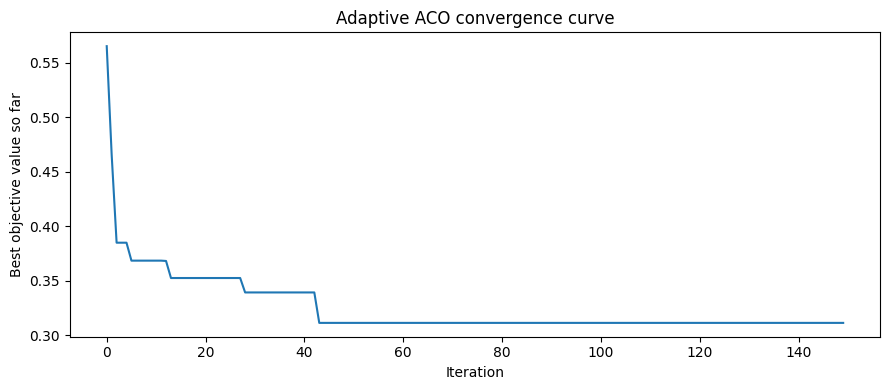

,iteration,best_iteration_cost,mean_iteration_cost,global_best_cost,global_best_cv_score,selected_features_global_best
0,1,0.565124,0.621160,0.565124,0.381746,6
1,2,0.465461,0.573421,0.465461,0.490873,5
2,3,0.384767,0.561610,0.384767,0.582143,6
3,4,0.523023,0.579503,0.384767,0.582143,6
4,5,0.406993,0.551834,0.384767,0.582143,6


,iteration,best_iteration_cost,mean_iteration_cost,global_best_cost,global_best_cv_score,selected_features_global_best
145,146,0.348023,0.481986,0.311175,0.662302,5
146,147,0.440186,0.528240,0.311175,0.662302,5
147,148,0.387604,0.521330,0.311175,0.662302,5
148,149,0.415502,0.481847,0.311175,0.662302,5
149,150,0.379493,0.496059,0.311175,0.662302,5


In [16]:
plt.figure()
plt.plot(selector.curve_)
plt.xlabel('Iteration')
plt.ylabel('Best objective value so far')
plt.title('Adaptive ACO convergence curve')
plt.tight_layout()
plt.savefig(output_dir / 'aco_convergence_curve.png', dpi=150, bbox_inches='tight')
plt.show()

display(selector.history_.head()) #you can save the entire history to see how it evolves
display(selector.history_.tail())


## 9. Final selected feature subset

Remember to save all the results obtained.

In [17]:
selected_idx = selector.get_selected_indices()
selected_features = selector.get_selected_feature_names()

selected_df = pd.DataFrame({
    'selected_rank': np.arange(1, len(selected_features) + 1),
    'feature': selected_features,
})

display(selected_df)

save_versioned(selected_df, 'LAB3_selected_features', 3)


,selected_rank,feature
0,1,age
1,2,std_platelets
2,3,comorb_catsystemic_immune_oncologic
3,4,first_PT
4,5,std_heart_rate


Saved → LAB3/outputs/20260617_210615/LAB3_selected_features.xlsx


PosixPath('/Users/lucaostinelli/Documents/repo/DAPPC/LAB3/outputs/20260617_210615/LAB3_selected_features.xlsx')